Dataset:
    Hours_Studied  Passed
0              1       0
1              2       0
2              3       0
3              4       0
4              5       0
5              6       1
6              7       1
7              8       1
8              9       1
9             10       1

Accuracy: 0.6666666666666666

Confusion Matrix:
 [[1 0]
 [1 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



C:\Users\Shafayet 777\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


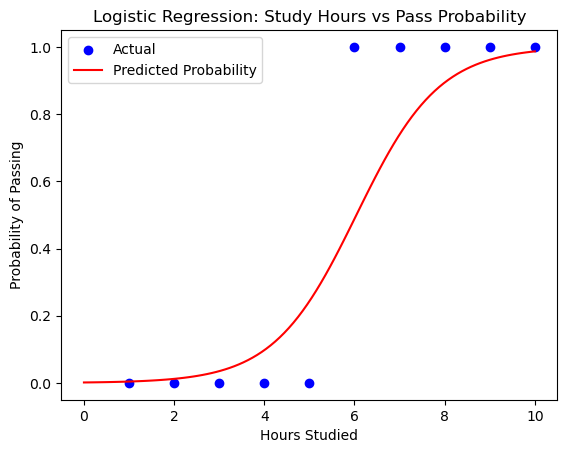


If a student studies 4.5 hours,
Probability of passing = 0.16
Prediction: Fail ❌


C:\Users\Shafayet 777\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\Users\Shafayet 777\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------
# Step 1: Create Dataset
# ---------------------------
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Passed':        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
print("Dataset:\n", df)

# ---------------------------
# Step 2: Split Data
# ---------------------------
X = df[['Hours_Studied']]   # Features
y = df['Passed']            # Labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------------------------
# Step 3: Train Logistic Regression Model
# ---------------------------
model = LogisticRegression()
model.fit(X_train, y_train)

# ---------------------------
# Step 4: Make Predictions
# ---------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # Probability of passing

# ---------------------------
# Step 5: Evaluate Model
# ---------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------------------
# Step 6: Visualization
# ---------------------------
plt.scatter(df['Hours_Studied'], df['Passed'], color='blue', label='Actual')
X_range = np.linspace(0, 10, 100).reshape(-1, 1)
y_range_prob = model.predict_proba(X_range)[:, 1]
plt.plot(X_range, y_range_prob, color='red', label='Predicted Probability')
plt.xlabel('Hours Studied')
plt.ylabel('Probability of Passing')
plt.title('Logistic Regression: Study Hours vs Pass Probability')
plt.legend()
plt.show()

# ---------------------------
# Step 7: Predict for new data
# ---------------------------
new_hours = [[4.5]]
pred_prob = model.predict_proba(new_hours)[0][1]
pred_class = model.predict(new_hours)[0]
print(f"\nIf a student studies {new_hours[0][0]} hours,")
print(f"Probability of passing = {pred_prob:.2f}")
print("Prediction:", "Pass ✅" if pred_class==1 else "Fail ❌")
